# 1. Препроцессинг датасета.

Необходимо провести чистку/восстановление признаков и отдельных экземпляров. Использовать тепловую матрицу для удаления сильно зависимых признаков, найти и выбрать наиболее важные для настройки модели признаки посредством алгоритма Gain Ratio (коэффициент усиления) из алгоритма классификации с помощью деревьев решений C4.5. Рассказать о проделанной работе и обосновать каждое преобразование датасета.

## Используемые библиотеки

In [ ]:
import pandas as pd # Обработка и анализ данных с файла
import numpy as np  # Для работы с многомерными массивами, числовыми данными
import matplotlib.pyplot as plt # Визуализация данных
import seaborn as sns # Статические графики
from scipy.stats import zscore

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectFromModel

print("Библиотеки успешно загружены!")

Библиотеки успешно загружены!


## Описание и демонстрация датасета

В качестве датасета выбран вариант "Цена на лаптопы".

Сам датасет выглядит следующим образом:

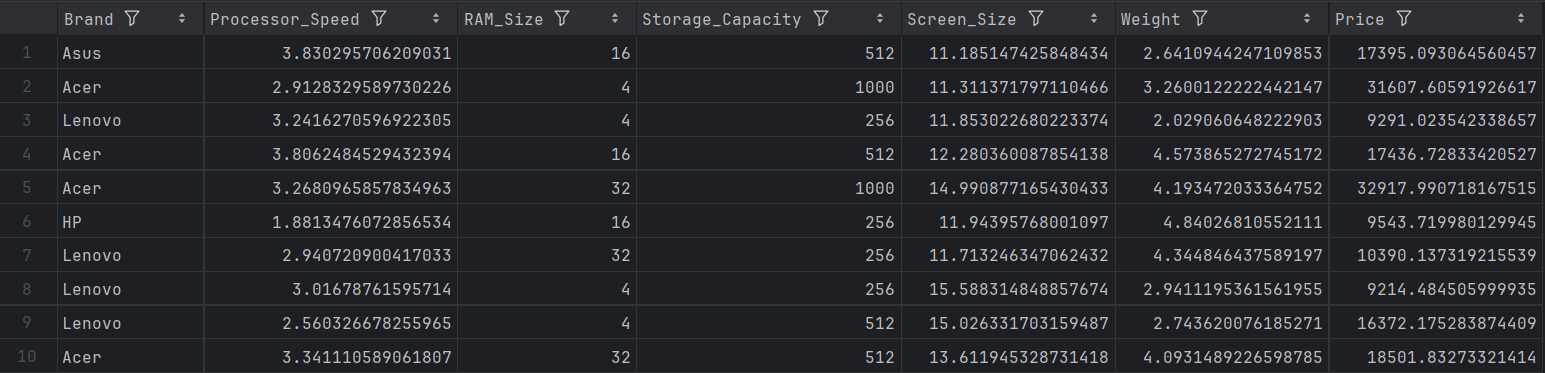


Для работы с датасетом используются функции библиотеки pandas языка Python. Для вывода информации (с выводом названий столбцов и количества ненулевых значений, описательной статистики для столбцов, количества пропущенных значений (NaN)) исполняется следующая программа:

In [ ]:
df = pd.read_csv("Laptop_price.csv")

print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB
None
       Processor_Speed     RAM_Size  Storage_Capacity  Screen_Size  \
count      1000.000000  1000.000000       1000.000000  1000.000000   
mean          2.750611    15.500000        584.576000    14.056790   
std           0.731796    10.988665        313.438517     1.705882   
min           1.511580     4.000000        256.000000    11.012111   
25%           2.089246     8.000000        256.000000 

Для вывода количества уникальных значений в столбцах исполняется программа:

In [ ]:
feature_names = df.columns.tolist()
for column in feature_names:
    print(df[column].value_counts(dropna=False))

Brand
Dell      210
Asus      206
Acer      204
Lenovo    190
HP        190
Name: count, dtype: int64
Processor_Speed
1.711980    1
3.830296    1
2.912833    1
3.241627    1
3.806248    1
           ..
2.627098    1
3.813921    1
3.835918    1
3.341111    1
2.560327    1
Name: count, Length: 1000, dtype: int64
RAM_Size
32    274
8     246
4     243
16    237
Name: count, dtype: int64
Storage_Capacity
256     357
1000    336
512     307
Name: count, dtype: int64
Screen_Size
16.561498    1
11.185147    1
11.311372    1
11.853023    1
12.280360    1
            ..
13.895003    1
12.871904    1
14.295859    1
13.611945    1
15.026332    1
Name: count, Length: 1000, dtype: int64
Weight
3.440883    1
2.641094    1
3.260012    1
2.029061    1
4.573865    1
           ..
2.018772    1
3.698645    1
3.092338    1
4.093149    1
2.743620    1
Name: count, Length: 1000, dtype: int64
Price
8807.696702     1
17395.093065    1
31607.605919    1
9291.023542     1
17436.728334    1
               ..
17

## Предварительная обработка датасета

Датасет не имеет пустых значений, а значит, нужно проверять датасет на наличие следующих проблем: дублирующиеся данные, неверные данные, шум и выбросы.

*Шум* — это случайные или систематические вариации, которые не несут полезной информации и искажают истинные закономерности в данных.
*Выброс* — это экстремальные значения во входных данных, которые находятся далеко за пределами других наблюдений.


#### 1) Проверка на дублирующиеся данные:


In [ ]:
# Проверка полных дубликатов строк
full_duplicates = df.duplicated()
print(f"Полных дубликатов строк: {full_duplicates.sum()}")

# Проверка частичных дубликатов (по ключевым полям)
# Например, если есть идентификатор, который должен быть уникальным
if 'id' in df.columns:
    id_duplicates = df['id'].duplicated()
    print(f"Дубликатов ID: {id_duplicates.sum()}")

Полных дубликатов строк: 0


Имеем 0 дубликатов; очищать нечего.

#### 2) Проверка данных на правильность:

In [ ]:
valid_ranges = {
    'Processor_Speed': (1.5, 4.0),
    'Screen_Size': (11, 17),
    'Weight': (2.0, 5.0)
}

# Для категориальных признаков - допустимые значения
valid_categories = {
    'Brand': ['Dell', 'HP', 'Lenovo', 'Asus', 'Acer'],
    'RAM_Size': [4, 8, 16, 32],
    'Storage_Capacity': [256, 512, 1000]
}

# Удаление дубликатов (на всякий случай)
df_clean = df.drop_duplicates()

# Проверка выхода за допустимые диапазоны
out_of_range_records = {}

for col, (min_val, max_val) in valid_ranges.items():
    if col in df_clean.columns:
        out_of_range = df_clean[(df_clean[col] < min_val) | (df_clean[col] > max_val)]
        if len(out_of_range) > 0:
            out_of_range_records[col] = len(out_of_range)
            print(f"Признак {col}: {len(out_of_range)} записей вне допустимого диапазона [{min_val}, {max_val}]")

            # Варианты обработки:
            # 1. Удаление записей
            # df_clean = df_clean[(df_clean[col] >= min_val) & (df_clean[col] <= max_val)]

            # 2. Замена на граничные значения
            df_clean.loc[df_clean[col] < min_val, col] = min_val
            df_clean.loc[df_clean[col] > max_val, col] = max_val
        else:
            print(f"Признак {col}: все записи входят в допустимый диапазон")

# Проверка категориальных признаков
for col, valid_vals in valid_categories.items():
    if col in df_clean.columns:
        invalid_cats = ~df_clean[col].isin(valid_vals)
        if invalid_cats.sum() > 0:
            print(f"Признак {col}: {invalid_cats.sum()} записей с недопустимыми категориями")
            print(f"Недопустимые значения: {df_clean[col][invalid_cats].unique()}")

            # Замена на 'other'
            df_clean.loc[invalid_cats, col] = 'other'
        else:
            print(f"Признак {col}: все записи входят в допустимый диапазон")

Признак Processor_Speed: все записи входят в допустимый диапазон
Признак Screen_Size: все записи входят в допустимый диапазон
Признак Weight: все записи входят в допустимый диапазон
Признак Brand: все записи входят в допустимый диапазон
Признак RAM_Size: все записи входят в допустимый диапазон
Признак Storage_Capacity: все записи входят в допустимый диапазон


Исходя из результатов, все записи находятся в допустимом диапазоне.


#### 3) Проверка на выбросы.

Проверим датасет на наличие выбросов несколькими способами:

In [ ]:
# Метод IQR
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f"По методу IQR: {len(outliers_iqr)} выбросов ({len(outliers_iqr)/len(df)*100:.1f}%)")

# Метод Z-оценки
z_scores = zscore(df['Price'])
outliers_zscore = df[abs(z_scores) > 3]
print(f"По Z-оценке (>3σ): {len(outliers_zscore)} выбросов ({len(outliers_zscore)/len(df)*100:.1f}%)")

# Применяем винзоризацию для цены (замена крайних значений)
price_percentiles = df['Price'].quantile([0.01, 0.99])
df_clean = df.copy()
df_clean['Price'] = df_clean['Price'].clip(price_percentiles[0.01], price_percentiles[0.99])

По методу IQR: 0 выбросов (0.0%)
По Z-оценке (>3σ): 0 выбросов (0.0%)


#### 4) Кодирование категориальных признаков

In [ ]:
label_encoder = LabelEncoder()
df['Brand_encoded'] = label_encoder.fit_transform(df['Brand'])
print(f"   Бренды закодированы: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

   Бренды закодированы: {'Acer': np.int64(0), 'Asus': np.int64(1), 'Dell': np.int64(2), 'HP': np.int64(3), 'Lenovo': np.int64(4)}


#### 5) Масштабирование числовых признаков

Необходимо, поскольку мы имеет разный масштаб для различных характеристик (объём памяти, размер экрана и т. д.)

In [ ]:
numeric_features = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                    'Screen_Size', 'Weight', 'Price', 'Brand_encoded']

scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df[numeric_features]),
    columns=numeric_features
)
print("Данные нормализованы: диапазон [0, 1]")
print(f"После стандартизации - среднее: {df_scaled_standard['Processor_Speed'].mean():.3f}, "
      f"std: {df_scaled_standard['Processor_Speed'].std():.3f}")

Данные нормализованы: диапазон [0, 1]
После стандартизации - среднее: -0.000, std: 1.001


## Построение тепловой матрицы



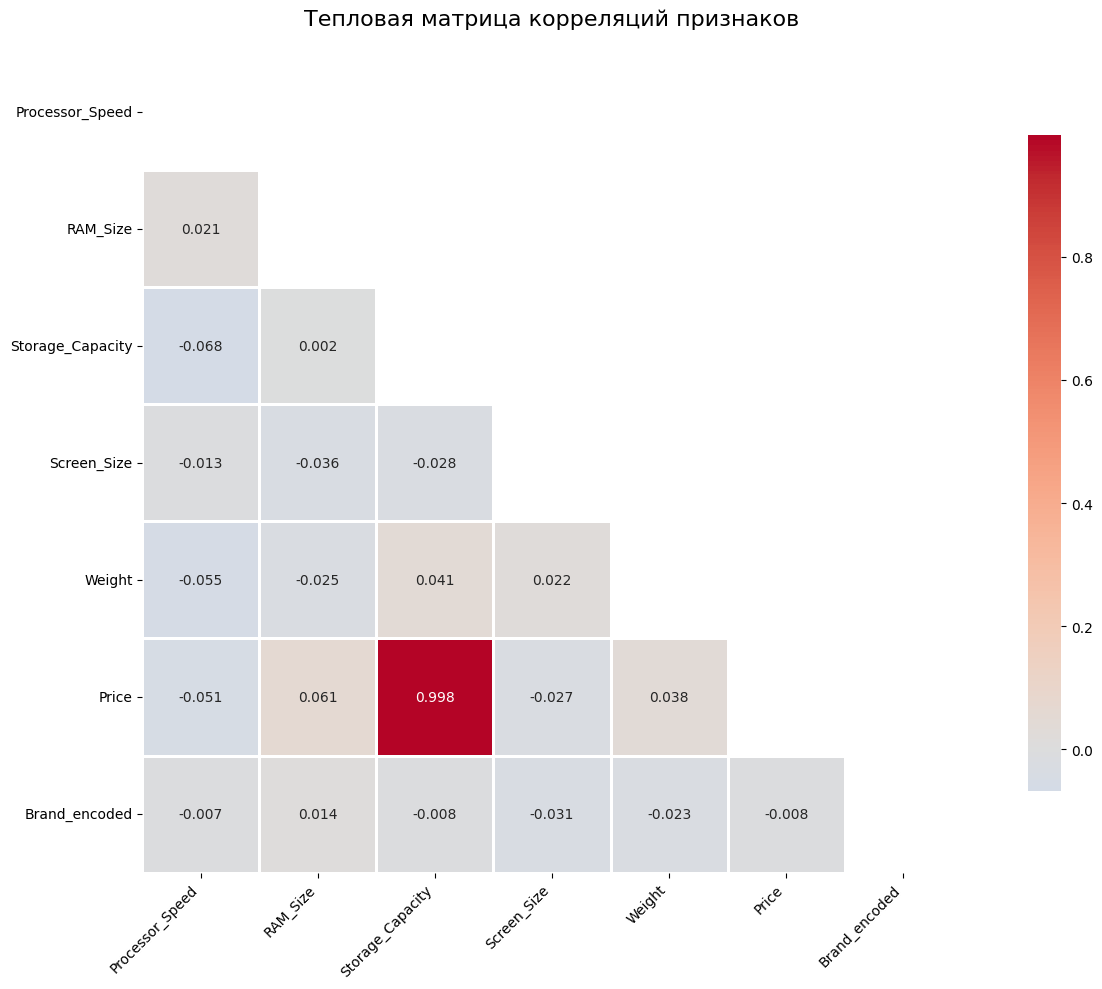


Признаки с высокой корреляцией (>0.85):
   Price — Storage_Capacity: 0.9979

Корреляция признаков с ценой (Price):
   Storage_Capacity: 0.9979
   RAM_Size: 0.0612
   Weight: 0.0384
   Brand_encoded: -0.0084
   Screen_Size: -0.0267
   Processor_Speed: -0.0507


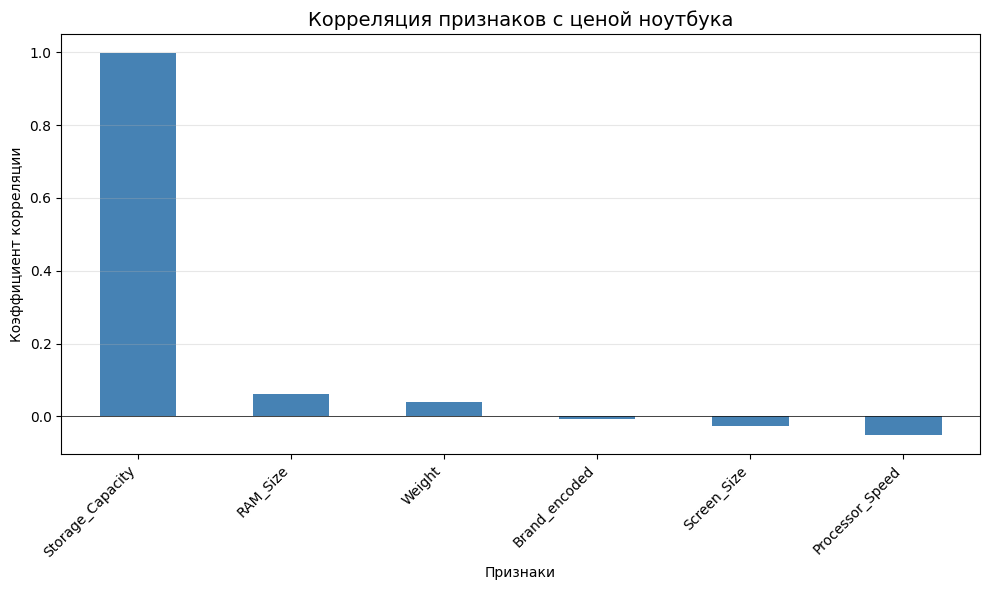

In [ ]:
# Вычисляем матрицу корреляций
correlation_matrix = df[numeric_features].corr()

label_encoder = LabelEncoder()
df['Brand_encoded'] = label_encoder.fit_transform(df['Brand'])

# Маска для верхнего треугольника
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=0)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Тепловая матрица корреляций признаков',
          fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Выявление сильно коррелированных признаков
print("\nПризнаки с высокой корреляцией (>0.85):")
high_corr_pairs = []
threshold = 0.85
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i],
                                   correlation_matrix.columns[j],
                                   correlation_matrix.iloc[i, j]))

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1} — {feat2}: {corr:.4f}")
else:
    print("   Признаков с высокой корреляцией не обнаружено")

# Корреляция признаков с целевой переменной
print("\nКорреляция признаков с ценой (Price):")
price_corr = correlation_matrix['Price'].sort_values(ascending=False)
for feat, corr in price_corr.items():
    if feat != 'Price':
        print(f"   {feat}: {corr:.4f}")

# Визуализация корреляции с ценой
plt.figure(figsize=(10, 6))
price_corr.drop('Price').plot(kind='bar', color='steelblue')
plt.title('Корреляция признаков с ценой ноутбука', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Коэффициент корреляции')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Матрица:

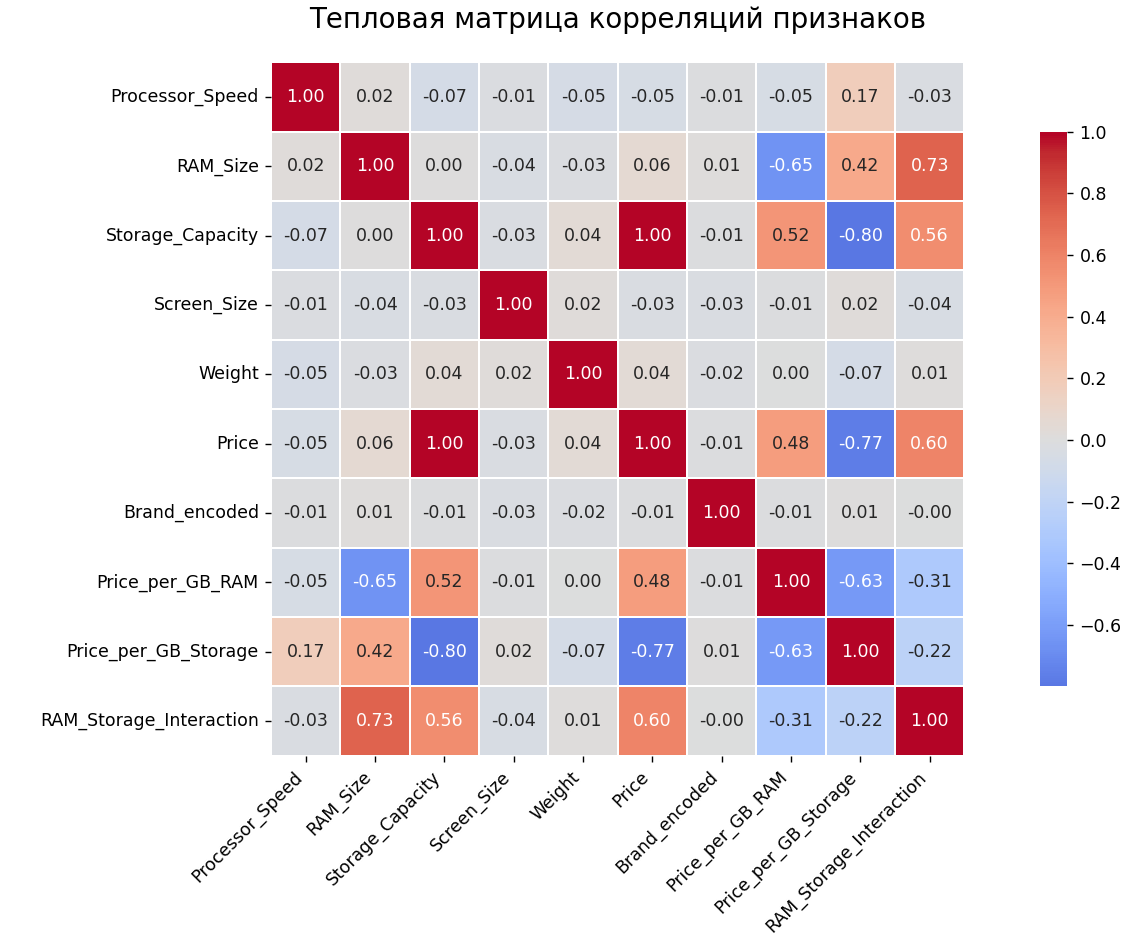 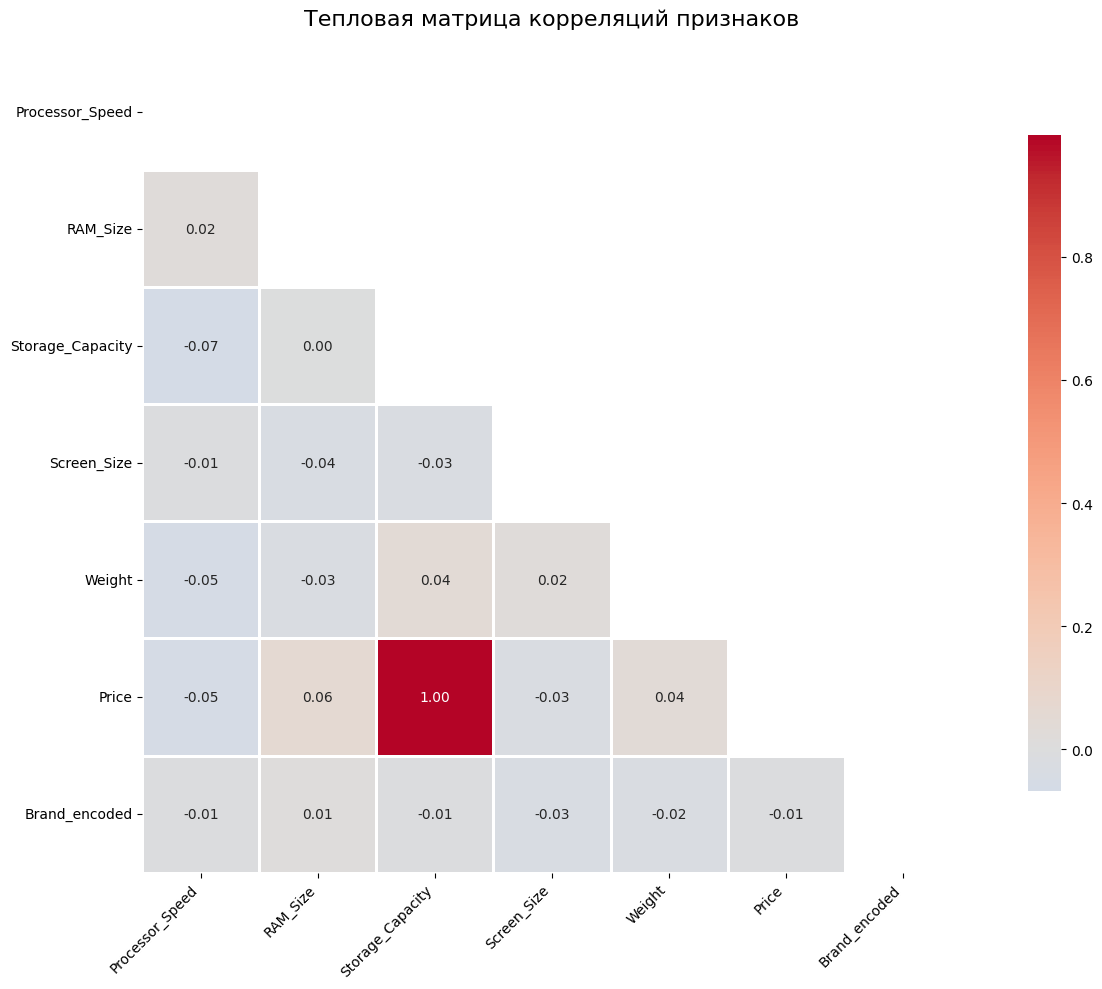

# Отбор признаков по Gain Ratio

Реализуем алгоритм C4.5, используя дерево из ```sklearn``` и вычисляя $Gain Ratio$ на основе его разбиений:

         Признак  Gain Ratio Лучшее разбиение
Storage_Capacity    0.738080      <= 384.0000
        RAM_Size    0.153287       <= 24.0000
     Screen_Size    0.079709       <= 11.0606
 Processor_Speed    0.033222        <= 3.9262
          Weight    0.007494        <= 2.7762
   Brand_encoded    0.001805        <= 0.5000


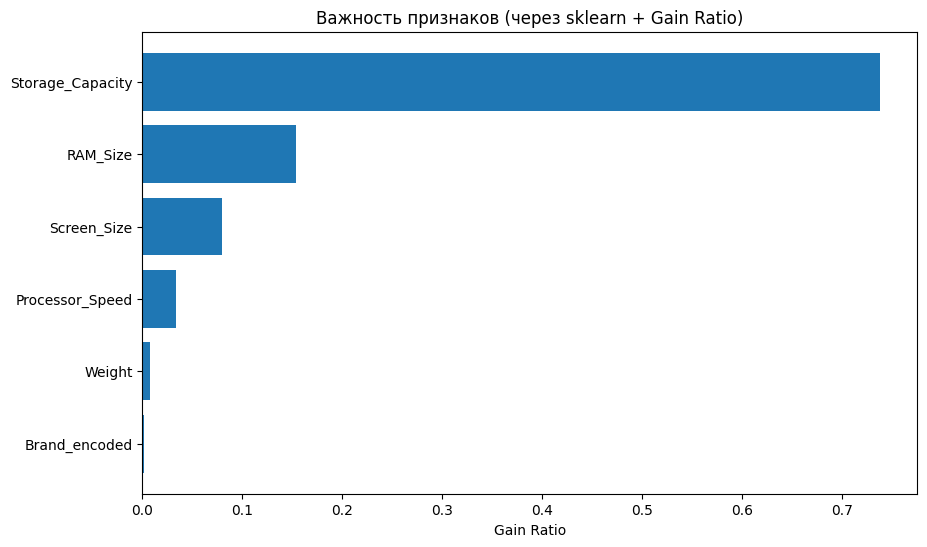


Отобрано признаков: ['Storage_Capacity', 'RAM_Size', 'Screen_Size']


In [ ]:
df['Price_Cat'] = pd.qcut(df['Price'], q=4,
                          labels=['low', 'medium_low', 'medium_high', 'high'])

class_mapping = {'low':0, 'medium_low':1, 'medium_high':2, 'high':3}
df['Price_class'] = df['Price_Cat'].map(class_mapping)

feature_columns = ['Brand_encoded', 'Processor_Speed', 'RAM_Size',
                   'Storage_Capacity', 'Screen_Size', 'Weight']

X = df[feature_columns].copy()
y = df['Price_class'].values

tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=1
)

results = []

def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-10))

def split_info(n_left, n_right):
    n = n_left + n_right
    p_left = n_left / n
    p_right = n_right / n
    return - (p_left * np.log2(p_left + 1e-10) +
              p_right * np.log2(p_right + 1e-10))

for i, col in enumerate(feature_columns):
    Xi = X[[col]]

    tree.fit(Xi, y)

    # Получаем параметры сплита
    feature = tree.tree_.feature[0]
    threshold = tree.tree_.threshold[0]

    if feature == -2:
        # Нет разбиения
        results.append({
            'Признак': col,
            'Gain Ratio': 0,
            'Лучшее разбиение': '-'
        })
        continue

    values = Xi.values.flatten()
    mask_left = values <= threshold
    mask_right = ~mask_left

    # --- Information Gain ---
    H_parent = entropy(y)
    H_left = entropy(y[mask_left])
    H_right = entropy(y[mask_right])

    n = len(y)
    n_left = np.sum(mask_left)
    n_right = np.sum(mask_right)

    IG = H_parent - (n_left/n * H_left + n_right/n * H_right)

    # --- Split Info ---
    SI = split_info(n_left, n_right)

    GR = IG / SI if SI != 0 else 0

    results.append({
        'Признак': col,
        'Gain Ratio': GR,
        'Лучшее разбиение': f"<= {threshold:.4f}"
    })

results_df = pd.DataFrame(results).sort_values('Gain Ratio', ascending=False)

print(results_df.to_string(index=False))

plt.figure(figsize=(10,6))
plt.barh(results_df['Признак'], results_df['Gain Ratio'])
plt.xlabel('Gain Ratio')
plt.title('Важность признаков (через sklearn + Gain Ratio)')
plt.gca().invert_yaxis()
plt.show()

selected = results_df[results_df['Gain Ratio'] > 0.05]['Признак'].tolist()
print(f"\nОтобрано признаков: {selected}")

Теперь реализуем вручную алгоритм C4.5, используя метрику Gain Ratio:

$$GainRatio(X) = \frac{InformationGain(X)}{SplitInfo(X)}$$

Распределение классов:
Price_Cat
low            250
medium_low     250
medium_high    250
high           250
Name: count, dtype: int64
РЕЗУЛЬТАТЫ РАСЧЁТА GAIN RATIO (C4.5)
         Признак  Gain Ratio Лучшее разбиение
Storage_Capacity    0.747922      <= 756.0000
     Screen_Size    0.204302       <= 11.0311
          Weight    0.175509        <= 2.0017
 Processor_Speed    0.175509        <= 3.9967
        RAM_Size    0.153287       <= 24.0000
   Brand_encoded    0.001805        <= 0.5000


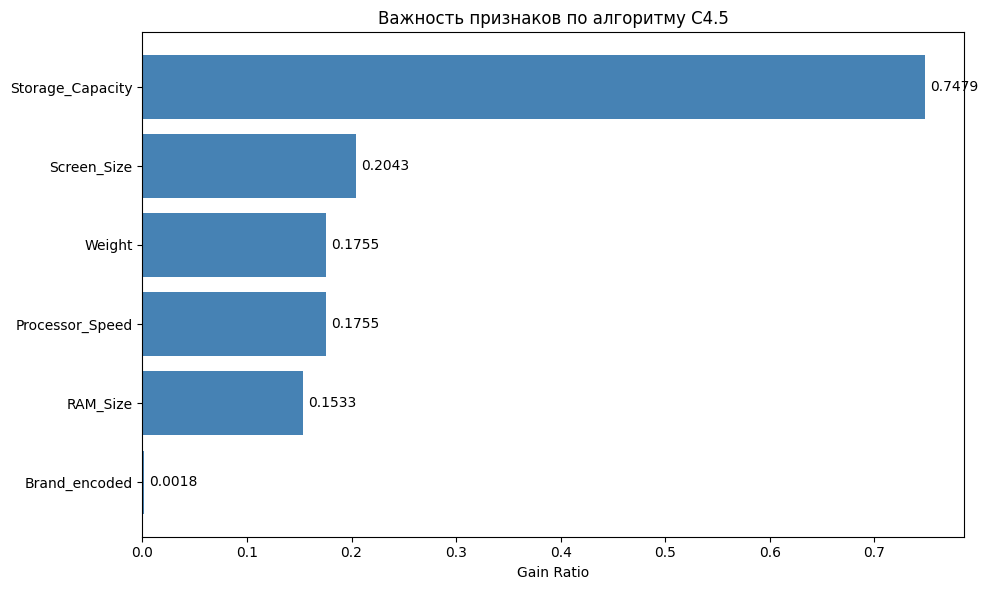


Отобрано признаков (Gain Ratio > 0.05): ['Storage_Capacity', 'Screen_Size', 'Weight', 'Processor_Speed', 'RAM_Size']


In [ ]:
print("Распределение классов:")
print(df['Price_Cat'].value_counts().sort_index())


def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-10))  # +1e-10 для избежания log(0)

def info_gain(y, mask_left, mask_right):
    n = len(y)
    n_left = np.sum(mask_left)
    n_right = np.sum(mask_right)
    if n_left == 0 or n_right == 0:
        return 0
    H_parent = entropy(y)
    H_left = entropy(y[mask_left])
    H_right = entropy(y[mask_right])
    return H_parent - (n_left/n * H_left + n_right/n * H_right)

def split_info(mask_left, mask_right):
    n = len(mask_left)
    n_left = np.sum(mask_left)
    n_right = np.sum(mask_right)
    if n_left == 0 or n_right == 0:
        return 0
    p_left = n_left / n
    p_right = n_right / n
    return - (p_left * np.log2(p_left) + p_right * np.log2(p_right))

def gain_ratio(y, mask_left, mask_right):
    """Gain Ratio = Info Gain / Split Info"""
    ig = info_gain(y, mask_left, mask_right)
    si = split_info(mask_left, mask_right)
    if si == 0:
        return 0
    return ig / si

def best_gain_ratio_continuous(series, y):
    values = series.values
    # Сортируем по значению признака
    sorted_idx = np.argsort(values)
    sorted_vals = values[sorted_idx]
    sorted_y = y[sorted_idx]

    best_gr = 0
    best_thr = None
    # Перебираем возможные пороги между соседними уникальными значениями
    unique_vals = np.unique(sorted_vals)
    for i in range(len(unique_vals)-1):
        thr = (unique_vals[i] + unique_vals[i+1]) / 2.0
        mask_left = values <= thr
        mask_right = ~mask_left
        gr = gain_ratio(y, mask_left, mask_right)
        if gr > best_gr:
            best_gr = gr
            best_thr = thr
    return best_gr, best_thr

def best_gain_ratio_categorical(series, y):
    """
    Для категориального признака рассматривает бинарные разбиения:
    каждая категория vs все остальные.
    Возвращает максимальный Gain Ratio и соответствующую категорию.
    """
    categories = series.unique()
    best_gr = 0
    best_cat = None
    for cat in categories:
        mask_left = series == cat
        mask_right = ~mask_left
        gr = gain_ratio(y, mask_left, mask_right)
        if gr > best_gr:
            best_gr = gr
            best_cat = cat
    return best_gr, best_cat

results = []
for col in feature_columns:
    if col == 'Brand':
        gr, best_param = best_gain_ratio_categorical(df[col], y)
        results.append({
            'Признак': col,
            'Gain Ratio': gr,
            'Лучшее разбиение': f"Бренд = {best_param}"
        })
    else:
        gr, thr = best_gain_ratio_continuous(df[col], y)
        results.append({
            'Признак': col,
            'Gain Ratio': gr,
            'Лучшее разбиение': f"<= {thr:.4f}" if thr is not None else "-"
        })

results_df = pd.DataFrame(results).sort_values('Gain Ratio', ascending=False)

print("РЕЗУЛЬТАТЫ РАСЧЁТА GAIN RATIO (C4.5)")
print(results_df.to_string(index=False))

plt.figure(figsize=(10,6))
plt.barh(results_df['Признак'], results_df['Gain Ratio'], color='steelblue')
plt.xlabel('Gain Ratio')
plt.title('Важность признаков по алгоритму C4.5')
plt.gca().invert_yaxis()
for i, v in enumerate(results_df['Gain Ratio']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

# Отбор признаков с порогом 0.05
selected = results_df[results_df['Gain Ratio'] > 0.05]['Признак'].tolist()
print(f"\nОтобрано признаков (Gain Ratio > 0.05): {selected}")

## Обучение модели

Размер обучающей выборки: (700, 6)
Размер тестовой выборки: (300, 6)

Выбрано признаков с важностью > 0.05: 1
Отобранные признаки: ['Storage_Capacity']


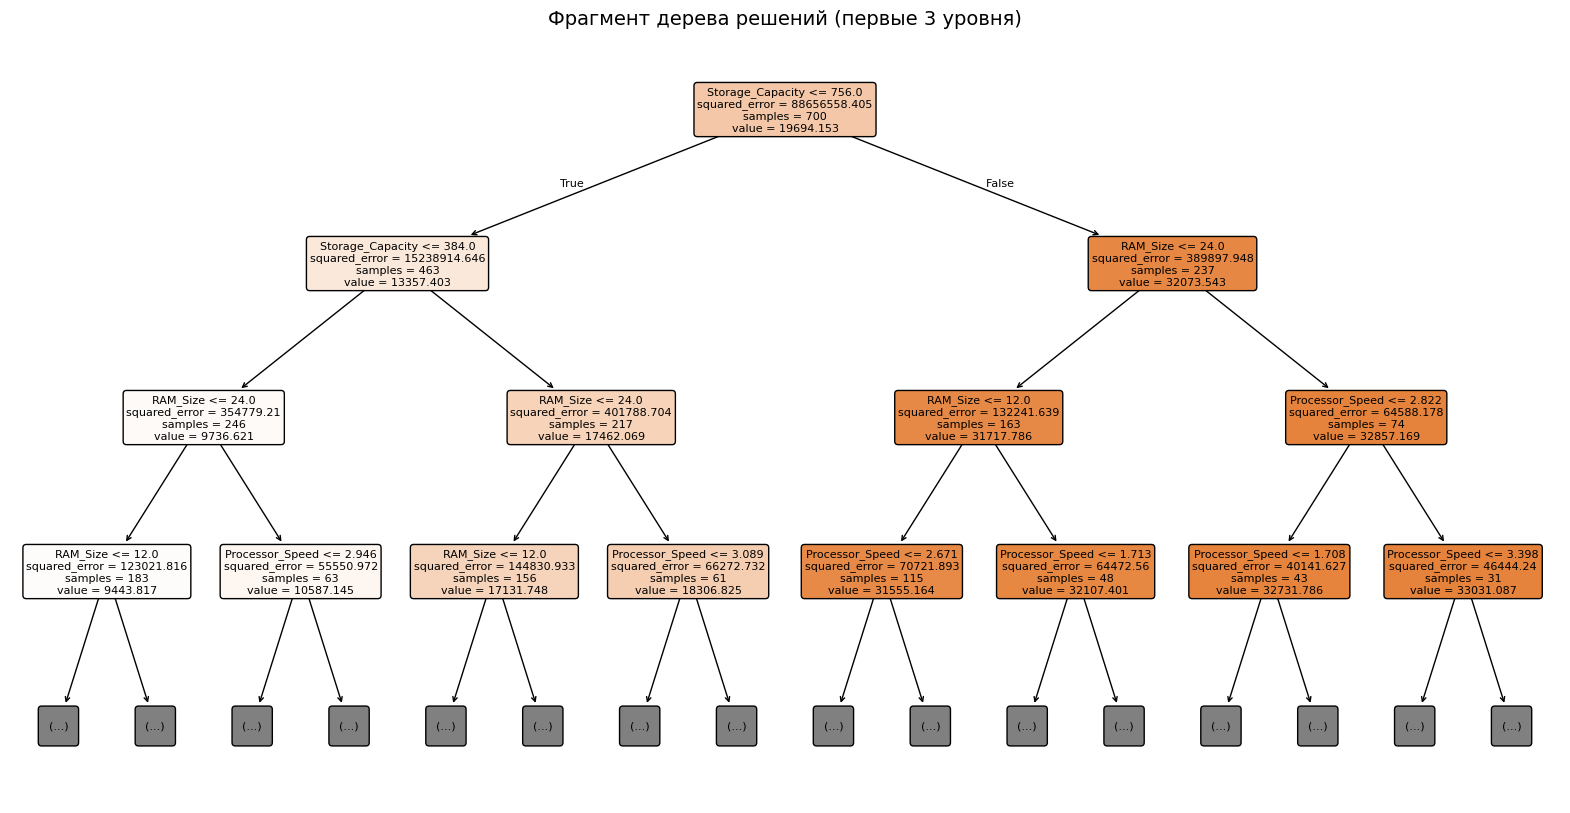

In [ ]:
df['Brand_encoded'] = label_encoder.fit_transform(df['Brand'])

feature_columns = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                   'Screen_Size', 'Weight', 'Brand_encoded']
target_column = 'Price'

X = df[feature_columns]
y = df[target_column]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Обучение дерева решений с энтропией (аналог C4.5)
dt_model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=0
)

dt_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

threshold = 0.05
selected_features = feature_importance[feature_importance['importance'] > threshold]['feature'].tolist()
print(f"\nВыбрано признаков с важностью > {threshold}: {len(selected_features)}")
print(f"Отобранные признаки: {selected_features}")

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=feature_columns, filled=True,
          rounded=True, fontsize=8, max_depth=3)
plt.title('Фрагмент дерева решений (первые 3 уровня)', fontsize=14)
plt.show()


## Прогнозы модели

In [ ]:
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

print("\nПервые 20 прогнозов на тестовой выборке:")
results_df = pd.DataFrame({
    'Фактическая цена': y_test.values[:20],
    'Прогнозируемая цена': y_test_pred[:20],
    'Абсолютная ошибка': np.abs(y_test.values[:20] - y_test_pred[:20]),
    'Относительная ошибка %': np.abs((y_test.values[:20] - y_test_pred[:20]) / y_test.values[:20] * 100)
})
print(results_df.round(2).to_string())

print("\nПРОГНОЗ ДЛЯ НОВОГО НОУТБУКА")

# Создаем пример нового ноутбука
new_laptop = pd.DataFrame({
    'Processor_Speed': [3.2],
    'RAM_Size': [16],
    'Storage_Capacity': [512],
    'Screen_Size': [15.6],
    'Weight': [2.5],
    'Brand_encoded': [label_encoder.transform(['Asus'])[0]]
})

# Прогнозируем цену
predicted_price = dt_model.predict(new_laptop)[0]

print("\nХарактеристики нового ноутбука:")
print(f"  Процессор: 3.2 ГГц")
print(f"  RAM: 16 ГБ")
print(f"  Хранилище: 512 ГБ")
print(f"  Экран: 15.6 дюймов")
print(f"  Вес: 2.5 кг")
print(f"  Бренд: Asus")
print(f"\nПрогнозируемая цена: {predicted_price:.2f}")

# Сравнение с похожими ноутбуками из датасета
similar_laptops = df_clean[
    (df_clean['RAM_Size'] == 16) &
    (df_clean['Storage_Capacity'] == 512) &
    (df_clean['Brand'] == 'Asus')
]['Price'].describe()

print("\nСтатистика цен похожих ноутбуков из датасета:")
print(f"  Средняя цена: {similar_laptops['mean']:.2f}")
print(f"  Мин цена: {similar_laptops['min']:.2f}")
print(f"  Макс цена: {similar_laptops['max']:.2f}")


Первые 20 прогнозов на тестовой выборке:
    Фактическая цена  Прогнозируемая цена  Абсолютная ошибка  Относительная ошибка %
0           31571.91             31819.12             247.21                    0.78
1           18743.57             18398.95             344.62                    1.84
2           10558.37             10532.62              25.76                    0.24
3           10461.21             10532.62              71.40                    0.68
4           16675.43             17019.48             344.05                    2.06
5            9213.79              9277.21              63.42                    0.69
6           31549.80             31276.23             273.57                    0.87
7           17242.83             17769.56             526.73                    3.05
8           17905.29             17769.56             135.73                    0.76
9           31727.41             31755.79              28.38                    0.09
10          31904.03   

## Графики

1. Важность признаков:

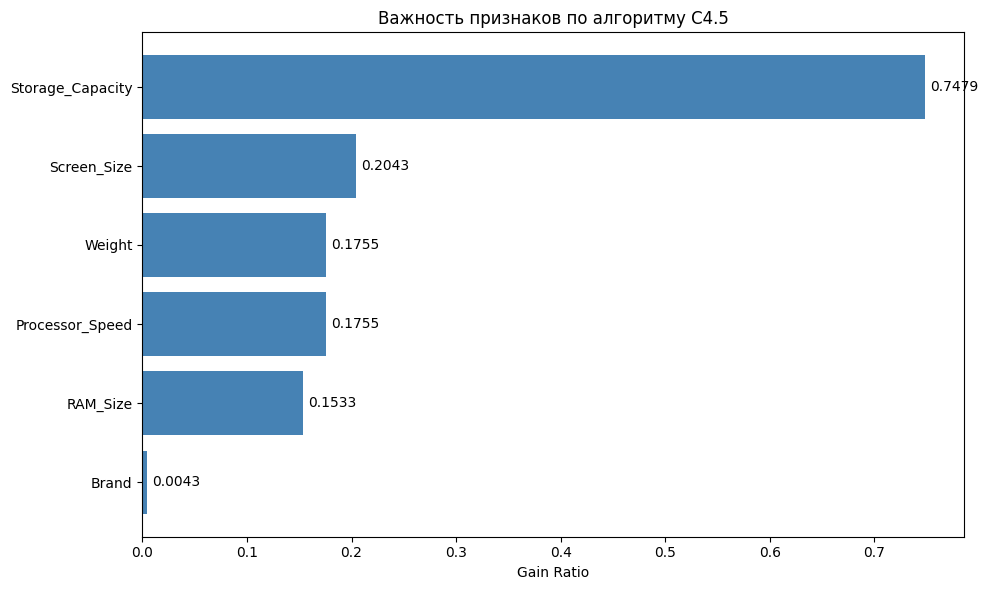

Корреляция признаков с ценой ноутбука:

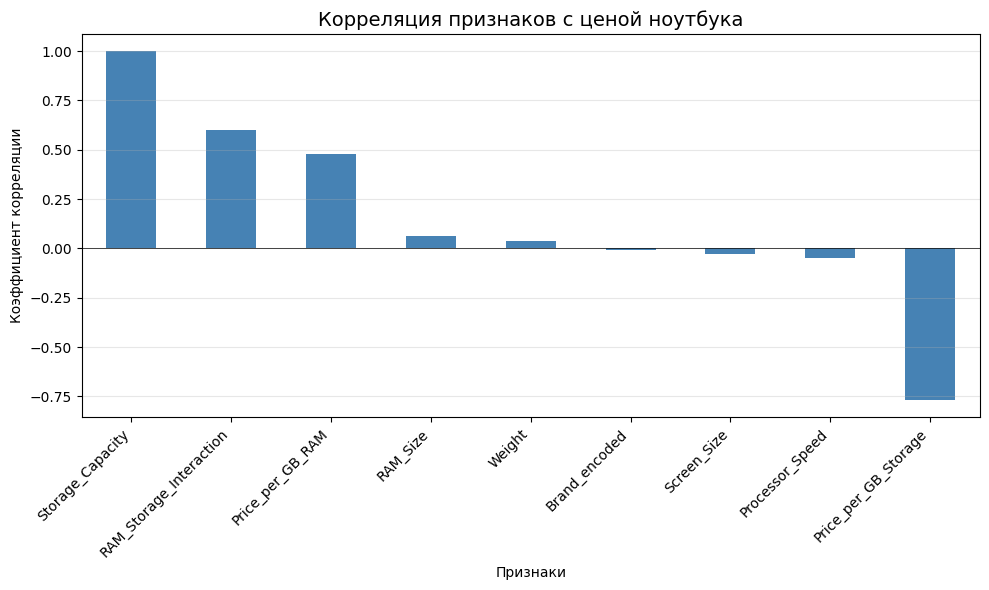

Дерево решений (первые три уровня):

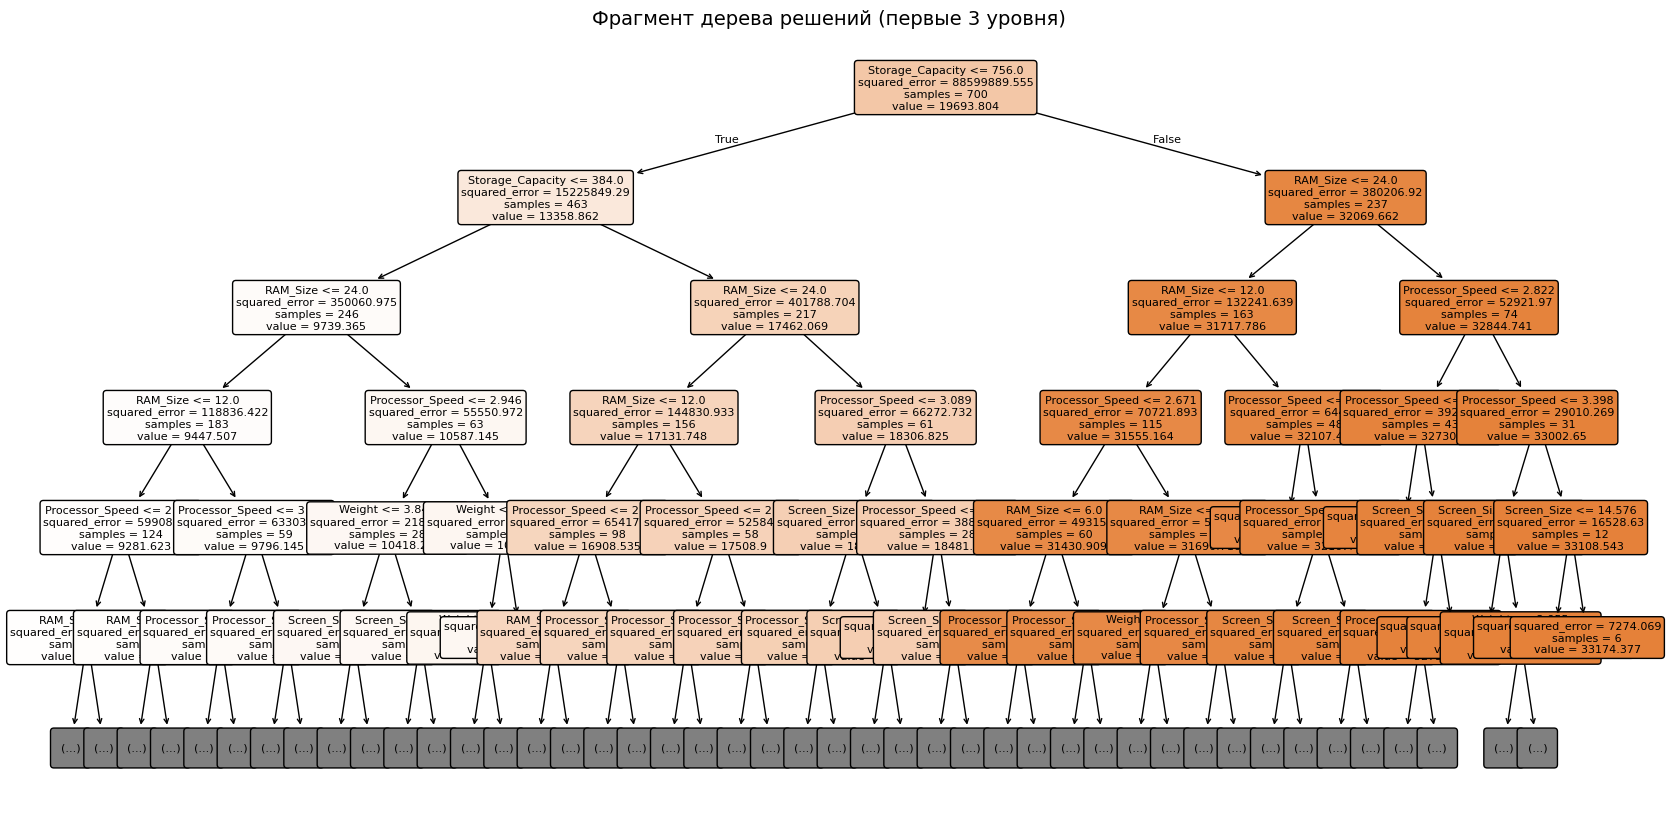

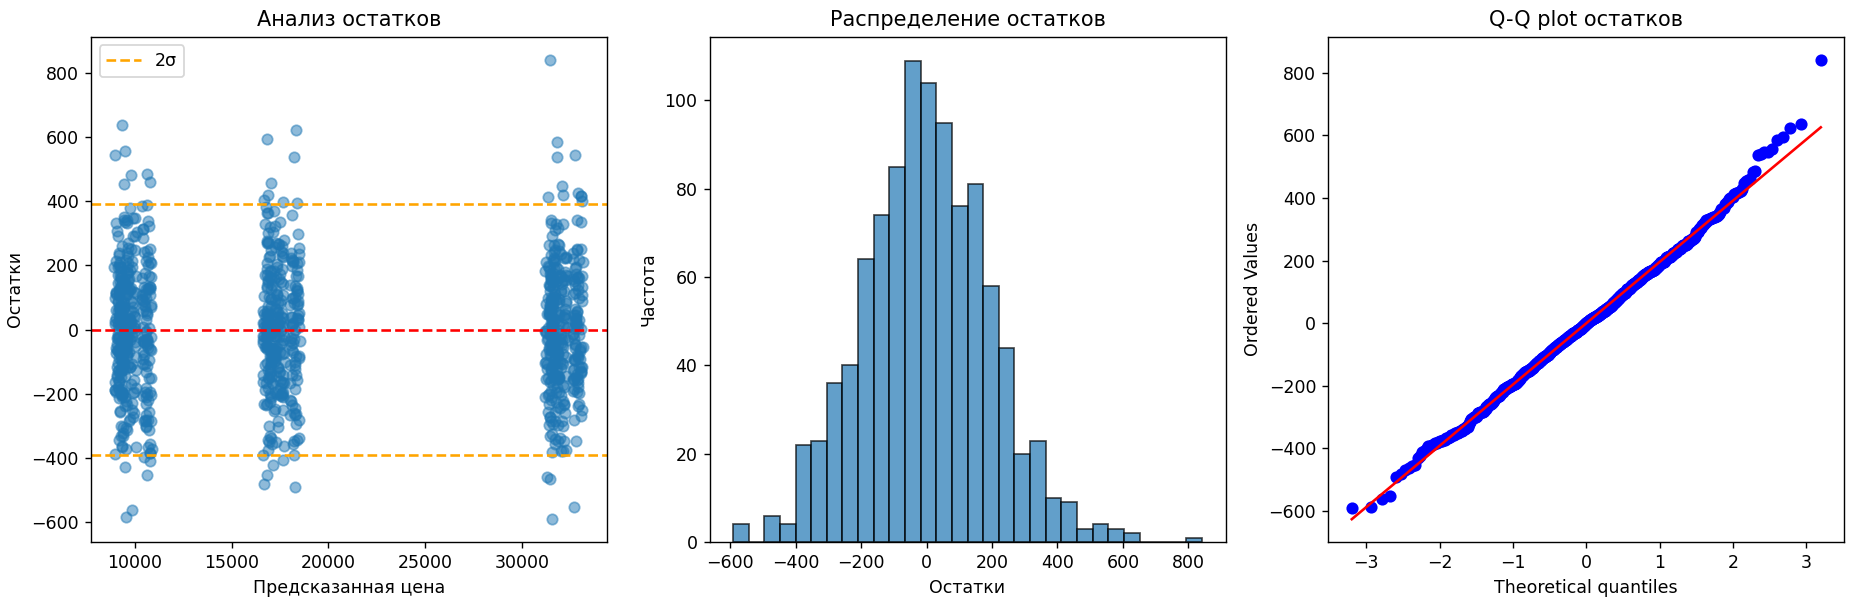